# **Superstore Sales Analysis**



## Group Members

| # | Student Name | Roll Number |
|:---:|:---|:---|
| 01 | **khansa Azeem** | **2023-AG-9564** |




## Step 1: Environment Setup
Installing required libraries and creating SparkSession.

In [2]:
import sys
!{sys.executable} -m pip install matplotlib pandas seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from pyspark.sql import SparkSession

print("PySpark imported successfully")

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import sum, col, round, desc, count
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Create SparkSession
spark = SparkSession.builder \
    .appName("Superstore Sales Analysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(" SparkSession created successfully!")
print(f"Spark version: {spark.version}")

## Step 2: Load Dataset
Loading the Superstore CSV file into a Spark DataFrame using SparkSession.

In [ ]:
# Load CSV into Spark DataFrame
df = spark.read.csv(
    "train.csv",
    header=True,
    inferSchema=True
)

print(f"Dataset loaded: {df.count()} rows, {len(df.columns)} columns\n")

# Preview schema and data
df.printSchema()
df.show(5, truncate=False)

Dataset loaded: 9800 rows, 18 columns

root
 |-- Row ID: integer (nullable = true)
 |-- Order ID: string (nullable = true)
 |-- Order Date: string (nullable = true)
 |-- Ship Date: string (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Customer ID: string (nullable = true)
 |-- Customer Name: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: integer (nullable = true)
 |-- Region: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub-Category: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Sales: string (nullable = true)

+------+--------------+----------+----------+--------------+-----------+---------------+---------+-------------+---------------+----------+-----------+------+---------------+---------------+------------+---------------------

In [ ]:
df = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("quote", "\"") \
    .option("escape", "\"") \
    .option("multiLine", "true") \
    .option("mode", "DROPMALFORMED") \
    .csv("train.csv")

In [ ]:
df.createOrReplaceTempView("sales_table")

## Step 3: Calculate Total Revenue
Using PySpark SQL to calculate Total Sales, Total Orders and Average Order value.

**Formula:** Total Revenue = SUM of all Sales values

In [ ]:
result = spark.sql("""
    SELECT 
        ROUND(SUM(Sales), 2) AS Total_Sales,
        COUNT(*) AS Total_Orders,
        ROUND(AVG(Sales), 2) AS Avg_Per_Order
    FROM sales_table
""")

result.show()                                                                                                                                                                                                           

+-----------+------------+-------------+
|Total_Sales|Total_Orders|Avg_Per_Order|
+-----------+------------+-------------+
| 2261536.78|        9800|       230.77|
+-----------+------------+-------------+



## Step 4: Group By Region
Grouping total sales by Region to identify which region 
generates the highest revenue.

In [ ]:
# Group by Region
region_df = spark.sql("""
    SELECT 
        Region,
        ROUND(SUM(Sales), 2) AS Total_Sales,
        COUNT(*) AS Total_Orders,
        ROUND(AVG(Sales), 2) AS Avg_Sales
    FROM sales_table
    GROUP BY Region
    ORDER BY Total_Sales DESC
""")

region_df.show()

+-------+-----------+------------+---------+
| Region|Total_Sales|Total_Orders|Avg_Sales|
+-------+-----------+------------+---------+
|   West|  710219.68|        3140|   226.18|
|   East|  669518.73|        2785|    240.4|
|Central|  492646.91|        2277|   216.36|
|  South|  389151.46|        1598|   243.52|
+-------+-----------+------------+---------+



## Step 5: Region Sales Visualization
Bar chart and Pie chart showing sales distribution across all regions.

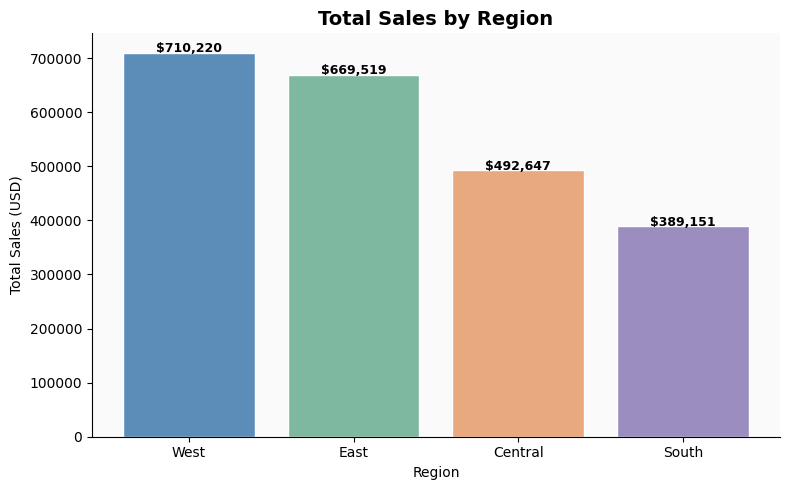

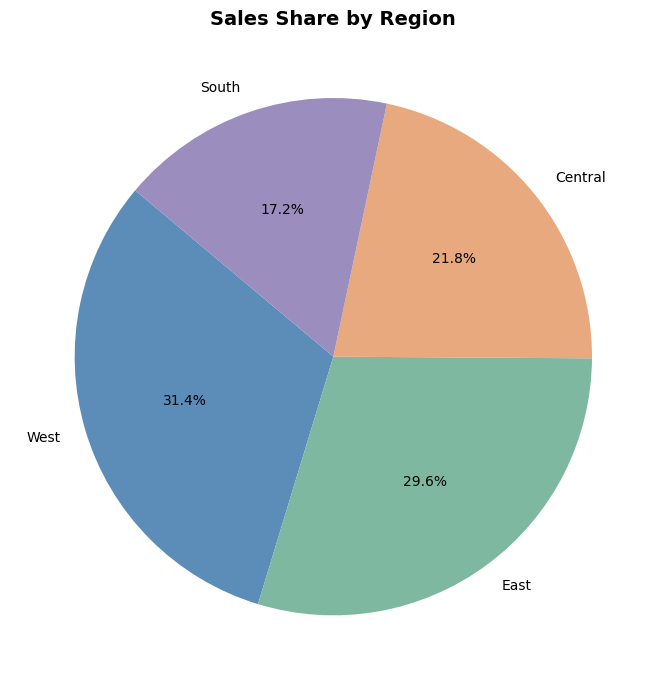

In [ ]:
region_pd = region_df.toPandas()
colors = ['#5B8DB8', '#7EB8A0', '#E8A97E', '#9B8DBE']

# Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(region_pd['Region'], region_pd['Total_Sales'],
               color=colors, edgecolor='white')
for bar, val in zip(bars, region_pd['Total_Sales']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales (USD)')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().set_facecolor('#FAFAFA')
plt.tight_layout()
plt.savefig('region_bar.png', dpi=150)
plt.show()

# Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(region_pd['Total_Sales'], labels=region_pd['Region'],
        autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Sales Share by Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('region_pie.png', dpi=150)
plt.show()

## Step 6: Find Highest Selling Product
Identifying the Top 10 highest selling products by total sales value
using GROUP BY and ORDER BY DESC.

In [ ]:
# Find highest selling products
product_df = spark.sql("""
    SELECT 
        `Product Name`,
        ROUND(SUM(Sales), 2) AS Total_Sales,
        COUNT(*) AS Times_Sold
    FROM sales_table
    GROUP BY `Product Name`
    ORDER BY Total_Sales DESC
    LIMIT 10
""")

product_df.show(truncate=False)

+---------------------------------------------------------------------------+-----------+----------+
|Product Name                                                               |Total_Sales|Times_Sold|
+---------------------------------------------------------------------------+-----------+----------+
|Canon imageCLASS 2200 Advanced Copier                                      |61599.82   |5         |
|Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind|27453.38   |10        |
|Cisco TelePresence System EX90 Videoconferencing Unit                      |22638.48   |1         |
|HON 5400 Series Task Chairs for Big and Tall                               |21870.58   |8         |
|GBC DocuBind TL300 Electric Binding System                                 |19823.48   |11        |
|GBC Ibimaster 500 Manual ProClick Binding System                           |19024.5    |9         |
|Hewlett Packard LaserJet 3310 Copier                                       |18839.69   |8 

## Step 7: Top Products Visualization
Horizontal bar chart showing Top 10 highest selling products by revenue.

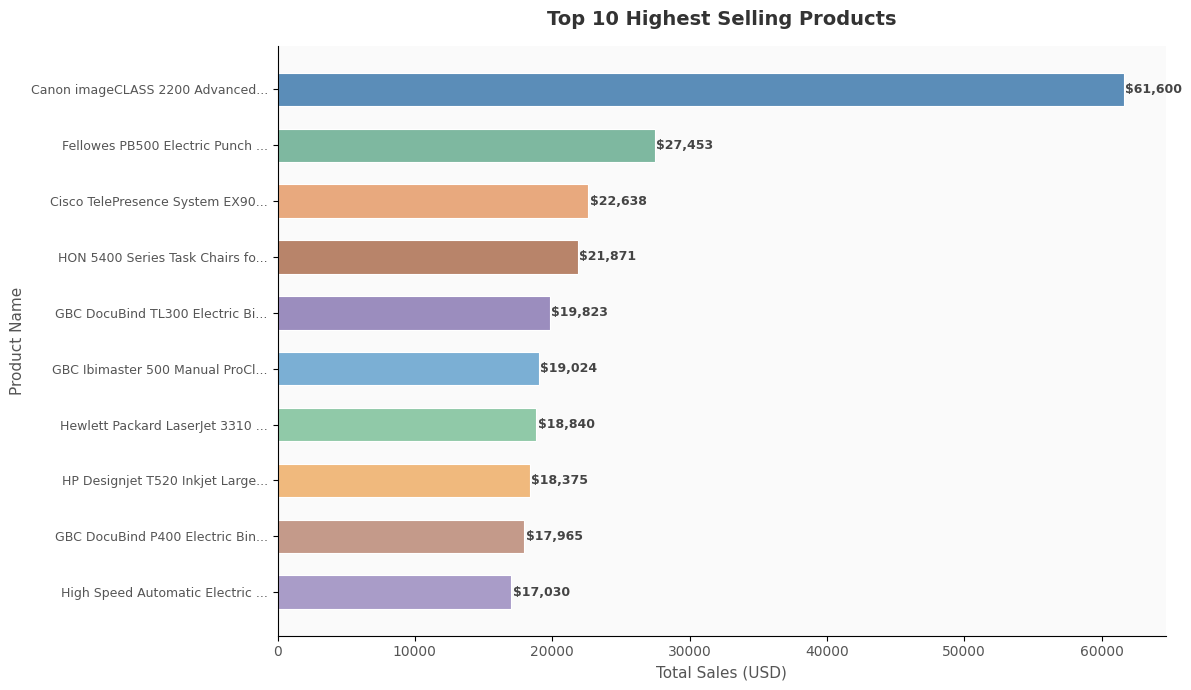

In [ ]:
# Convert to Pandas for plotting
product_pd = product_df.toPandas()

# Shorten long product names for display
product_pd['Short_Name'] = product_pd['Product Name'].str[:30] + '...'

# Sort ascending so highest appears at top
product_pd = product_pd.sort_values('Total_Sales', ascending=True)

# Professional pastel colors
pastel_colors = ['#A99CC8', '#C49A8A', '#F0B97D', '#90C9A8', '#7BAFD4',
                 '#9B8DBE', '#B8846A', '#E8A97E', '#7EB8A0', '#5B8DB8']

# Horizontal Bar Chart
plt.figure(figsize=(12, 7))
bars = plt.barh(product_pd['Short_Name'],
                product_pd['Total_Sales'],
                color=pastel_colors,
                edgecolor='white',
                linewidth=0.8,
                height=0.6)

# Value labels at end of each bar
for bar, val in zip(bars, product_pd['Total_Sales']):
    plt.text(bar.get_width() + 100,
             bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}',
             va='center', ha='left',
             fontsize=9, fontweight='bold', color='#444444')

# Professional styling
plt.title('Top 10 Highest Selling Products', fontsize=14,
          fontweight='bold', color='#333333', pad=15)
plt.xlabel('Total Sales (USD)', color='#555555', fontsize=11)
plt.ylabel('Product Name', color='#555555', fontsize=11)
plt.xticks(color='#555555')
plt.yticks(fontsize=9, color='#555555')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().set_facecolor('#FAFAFA')
plt.tight_layout()
plt.savefig('top_products_horizontal.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Top 5 States by Sales

Identifying the **Top 5 States** that generate the highest revenue
using `GROUP BY State` and `ORDER BY Total_Sales DESC`.


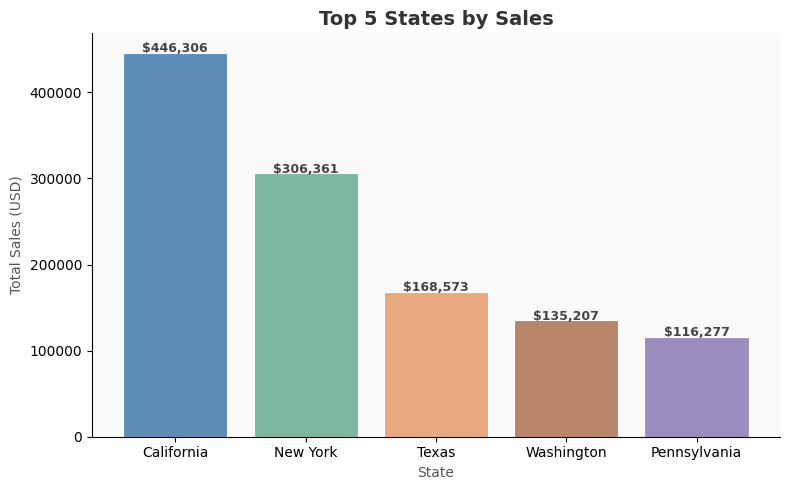

In [ ]:
# Professional pastel color palettes used by data scientists

# Soft blue palette (for single color charts)
single_color = '#5B8DB8'

# Multi color pastel palette
pastel_colors = ['#5B8DB8', '#7EB8A0', '#E8A97E', '#B8846A', '#9B8DBE']

# ---- Top 5 States ----
state_df = spark.sql("""
    SELECT State,
           ROUND(SUM(Sales), 2) AS Total_Sales
    FROM sales_table
    GROUP BY State
    ORDER BY Total_Sales DESC
    LIMIT 5
""").toPandas()

plt.figure(figsize=(8, 5))
bars = plt.bar(state_df['State'], state_df['Total_Sales'],
               color=pastel_colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, state_df['Total_Sales']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold',
             color='#444444')

plt.title('Top 5 States by Sales', fontsize=14, fontweight='bold', color='#333333')
plt.xlabel('State', color='#555555')
plt.ylabel('Total Sales (USD)', color='#555555')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().set_facecolor('#FAFAFA')
plt.tight_layout()
plt.savefig('top_states.png', dpi=150)
plt.show()

### **Project Summary: Superstore Sales Analysis**

I have successfully completed a big data project on **Superstore Sales Analysis** utilizing *Apache PySpark* for scalable data processing and *Matplotlib* for visualization. Working with the *Kaggle Superstore Dataset*—which encompasses *9,800 rows* and *18 columns*—I loaded the data via `SparkSession` and performed key transformations, including calculating **Total Revenue**, grouping sales by region, and isolating top-performing products. The analysis revealed a **Total Sales** milestone of **$2,261,536.78** across **9,800 orders**, identifying the **West** as the *Top Region* and the **Canon imageCLASS 2200 Advanced Copier** as the *Top Product*.